### Dataset

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

In [106]:
# Load historical data
db_url = "Dataset-SolarTechLab.csv"
df = pd.read_csv(db_url, delimiter=";")

In [107]:
df.head()

,Time,PV_Power,T_air,G_h,G_tilt,W_s,W_d
0,01-Jan-2017 00:00:00,NaN,0.74,0.0,0.0,0.30,296.4
1,01-Jan-2017 00:01:00,NaN,0.67,0.0,0.0,0.47,269.2
2,01-Jan-2017 00:02:00,NaN,0.57,0.0,0.0,0.84,265.3
3,01-Jan-2017 00:03:00,NaN,0.53,0.0,0.0,0.63,275.4
4,01-Jan-2017 00:04:00,NaN,0.53,0.0,0.0,0.58,265.3


In [108]:
columns = df.columns
print("Before columns:", columns)

cols = ['Date', 'Power_W', 'Temp_Celsius', 'Irradiance_horizontalPlane', 'Irradiance_inclinedPlane', 'Wind_speed', 'Wind_direction']
df.columns = cols

print("After columns:", df.columns)

Before columns: Index(['Time', 'PV_Power', 'T_air', 'G_h', 'G_tilt', 'W_s', 'W_d'], dtype='str')
After columns: Index(['Date', 'Power_W', 'Temp_Celsius', 'Irradiance_horizontalPlane',
       'Irradiance_inclinedPlane', 'Wind_speed', 'Wind_direction'],
      dtype='str')


In [109]:
types = df.dtypes
print(types)

Date                              str
Power_W                       float64
Temp_Celsius                  float64
Irradiance_horizontalPlane    float64
Irradiance_inclinedPlane      float64
Wind_speed                    float64
Wind_direction                float64
dtype: object


### Data Conversion

In [110]:
#transform Date in a datetime format
example = df["Date"].iloc[0]
print(f"Before transformation: {example}")

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%Y %H:%M:%S"
)

example = df["Date"].iloc[0]
print(f"After transformation: {example}")

Before transformation: 01-Jan-2017 00:00:00
After transformation: 2017-01-01 00:00:00


In [111]:
wind_direction = df["Wind_direction"].dropna().drop_duplicates().sort_values(ascending=True)  # Drop null values for wind direction
print(wind_direction)

labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
def encode_wind_direction(direction_numeric):
    if direction_numeric < 22.5 or direction_numeric >= 337.5:
        return 'N'
    elif 22.5 <= direction_numeric < 67.5:
        return 'NE'
    elif 67.5 <= direction_numeric < 112.5:
        return 'E'
    elif 112.5 <= direction_numeric < 157.5:
        return 'SE'
    elif 157.5 <= direction_numeric < 202.5:
        return 'S'
    elif 202.5 <= direction_numeric < 247.5:
        return 'SW'
    elif 247.5 <= direction_numeric < 292.5:
        return 'W'
    elif 292.5 <= direction_numeric < 337.5:
        return 'NW'
df['Wind_direction_encoded'] = df['Wind_direction'].apply(encode_wind_direction)
print(df[['Wind_direction', 'Wind_direction_encoded']].head())

53        0.0
205       0.1
445       0.2
3528      0.3
1556      0.4
        ...  
4978    358.6
3115    358.7
3159    358.8
3427    358.9
5785    359.0
Name: Wind_direction, Length: 3591, dtype: float64
   Wind_direction Wind_direction_encoded
0           296.4                     NW
1           269.2                      W
2           265.3                      W
3           275.4                      W
4           265.3                      W


### Outliers

In [112]:
temperatures = df["Temp_Celsius"].dropna().drop_duplicates().sort_values(ascending=True)  # Drop null values for temperature
min = temperatures.min()
max = temperatures.max()

print(f"Temperature range: {min} to {max}")

temperatures

Temperature range: -999999.0 to 38.16


56764    -999999.00
12045         -4.04
12042         -4.03
12041         -4.02
11815         -4.00
            ...    
310634        37.26
312079        37.29
310416        37.32
309041        37.41
104710        38.16
Name: Temp_Celsius, Length: 4074, dtype: float64

In [113]:
for temp in temperatures:
    if temp < -273.15:
        df.loc[df["Temp_Celsius"] == temp, "Temp_Celsius"] = -273.15


temperatures = df["Temp_Celsius"].dropna().drop_duplicates().sort_values(ascending=True)  # Drop null values for temperature
min = temperatures.min()
max = temperatures.max()
print(f"Temperature range after correction: {min} to {max}")

Temperature range after correction: -273.15 to 38.16


In [114]:
power = df["Power_W"].dropna().drop_duplicates().sort_values(ascending=True)  # Drop null values for power
min_power = power.min()
max_power = power.max()
print(f"Power range: {min_power} to {max_power}")

Power range: 0.31640625 to 59700.9507751465


### Null Val

In [115]:
null_vals = df.isnull().sum().sort_values()
print(null_vals)

Date                               0
Temp_Celsius                    4854
Irradiance_horizontalPlane      4854
Irradiance_inclinedPlane        4854
Wind_direction                  4854
Wind_speed                      4854
Wind_direction_encoded          4854
Power_W                       326871
dtype: int64


In [116]:
perc_null_val = df.isnull().sum() / len(df) * 100
print(perc_null_val)

Date                           0.000000
Power_W                       62.189950
Temp_Celsius                   0.923514
Irradiance_horizontalPlane     0.923514
Irradiance_inclinedPlane       0.923514
Wind_speed                     0.923514
Wind_direction                 0.923514
Wind_direction_encoded         0.923514
dtype: float64


In [117]:
# replace null values with 0
df["Power_W"] = df["Power_W"].fillna(0)

In [118]:
# remove all the other lines with null values
df = df.dropna()

perc_null_val = df.isnull().sum() / len(df) * 100
print(perc_null_val)

Date                          0.0
Power_W                       0.0
Temp_Celsius                  0.0
Irradiance_horizontalPlane    0.0
Irradiance_inclinedPlane      0.0
Wind_speed                    0.0
Wind_direction                0.0
Wind_direction_encoded        0.0
dtype: float64


### Save

In [119]:
df.to_csv("Dataset-SolarTechLabEngineered.csv", index=False)

In [120]:
image_path = 'images/'

### Stats

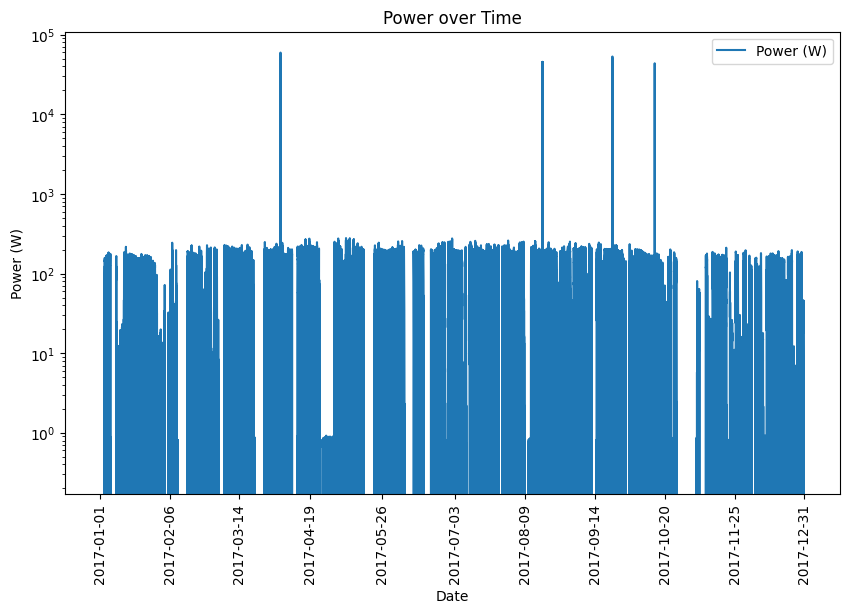

In [121]:
# Graph 1: Power over time

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale('log')
ax.plot(df["Date"], df["Power_W"], label="Power (W)")
ax.set_xlabel("Date")
ax.set_ylabel("Power (W)")
ax.set_title("Power over Time")
ax.set_xticks(df["Date"][::len(df)//10])  # Set x-ticks to show every 10% of the data
ax.tick_params(axis='x', rotation=90)  # Rotate x-ticks for better visibility
ax.legend()
plt.show()

save_path = image_path + "power_over_time.png"
fig.savefig(save_path)

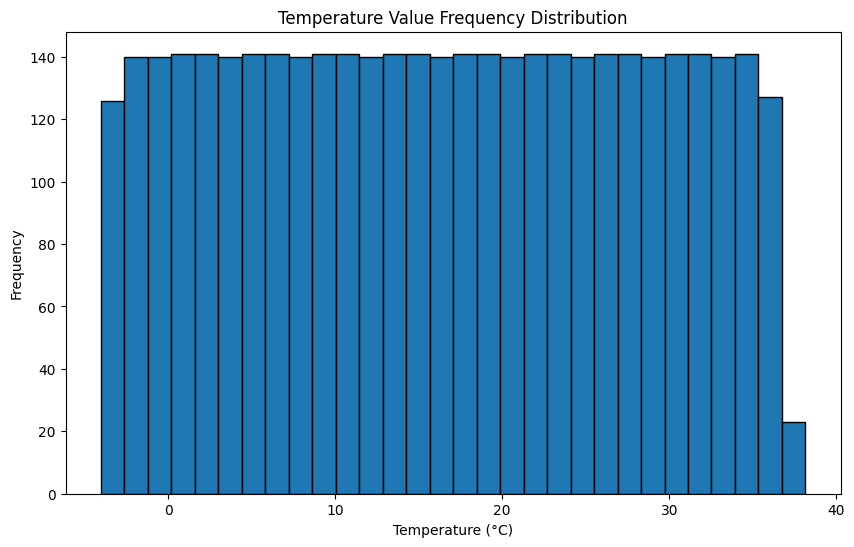

In [122]:
# Graph 2: Temperature val frequency distribution

fig, ax = plt.subplots(figsize=(10, 6))
temperatures = df["Temp_Celsius"].dropna().drop_duplicates().sort_values(ascending=True)  # Drop null values for temperature
temperatures = temperatures[temperatures > -263.15]  # Filter out temperatures below absolute zero
min = temperatures.min()
max = temperatures.max()
ax.hist(temperatures, bins=30, edgecolor='black')
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Frequency")
ax.set_title("Temperature Value Frequency Distribution")
plt.show()

save_path = image_path + "temperature_distribution.png"
fig.savefig(save_path)

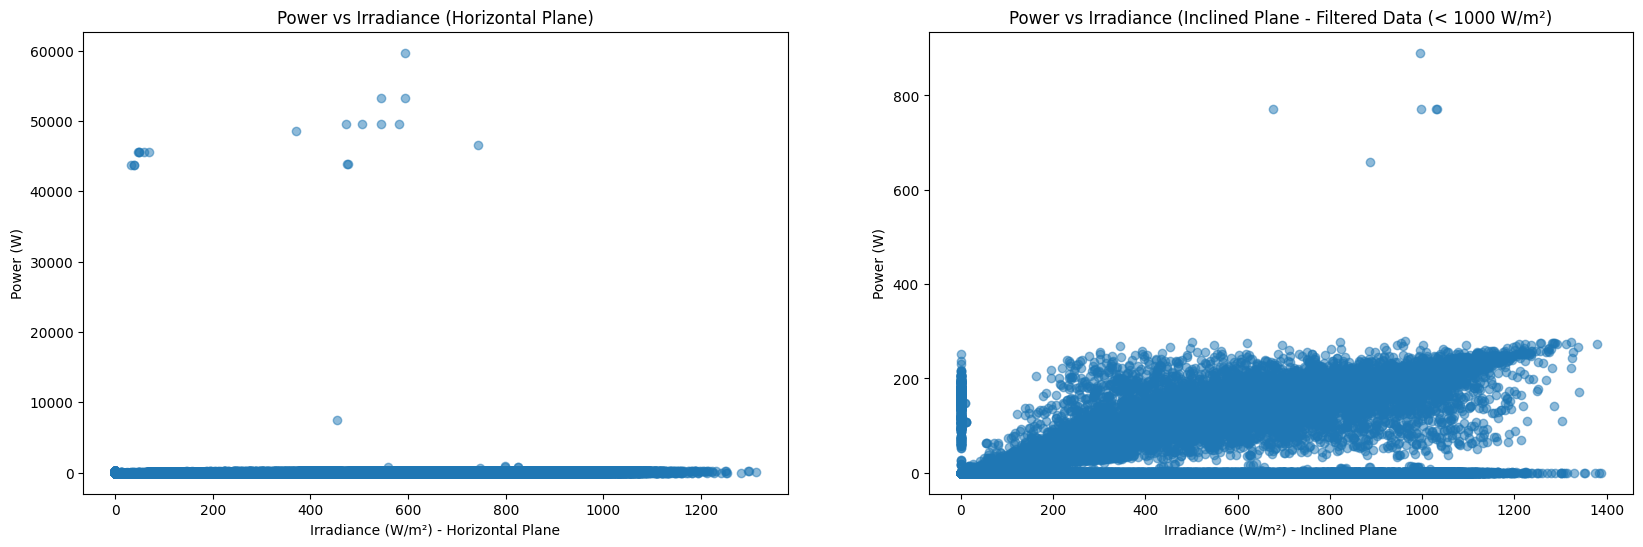

In [123]:
# Graph 3: Power vs Irradiance (horizontal plane)

fig, axs = plt.subplots(1, 2, figsize=(20, 6))
axs[0].scatter(df["Irradiance_horizontalPlane"], df["Power_W"], alpha=0.5)
axs[0].set_xlabel("Irradiance (W/m²) - Horizontal Plane")
axs[0].set_ylabel("Power (W)")
axs[0].set_title("Power vs Irradiance (Horizontal Plane)")
filtered_df = df[df["Power_W"] < 1000]
axs[1].scatter(filtered_df["Irradiance_inclinedPlane"], filtered_df["Power_W"], alpha=0.5)
axs[1].set_xlabel("Irradiance (W/m²) - Inclined Plane")
axs[1].set_ylabel("Power (W)")
axs[1].set_title("Power vs Irradiance (Inclined Plane - Filtered Data (< 1000 W/m²)")
plt.show()

save_path = image_path + "power_vs_irradiance.png"
fig.savefig(save_path)

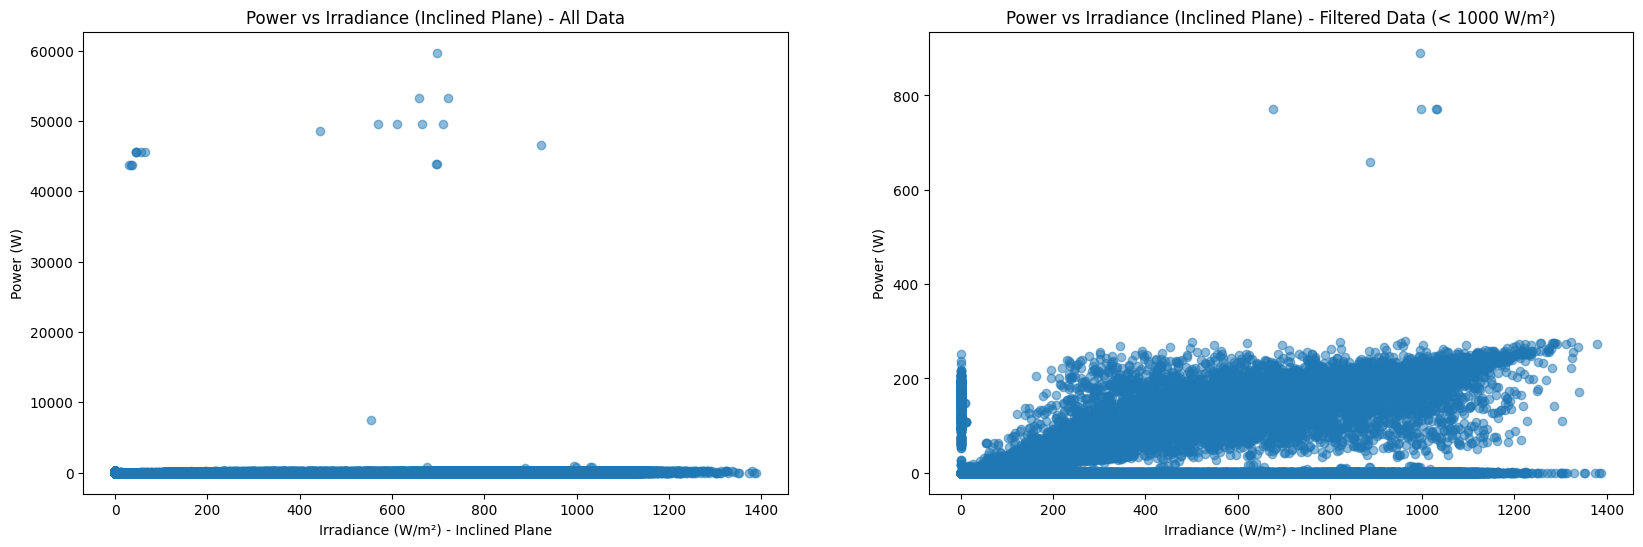

In [124]:
# Graph 4: Power vs Irradiance (inclined plane). 

fig, axs = plt.subplots(1, 2, figsize=(20, 6))
axs[0].scatter(df["Irradiance_inclinedPlane"], df["Power_W"], alpha=0.5)
axs[0].set_xlabel("Irradiance (W/m²) - Inclined Plane")
axs[0].set_ylabel("Power (W)")
axs[0].set_title("Power vs Irradiance (Inclined Plane) - All Data")
df_filtered = df[df['Power_W'] < 1000]
axs[1].scatter(df_filtered["Irradiance_inclinedPlane"], df_filtered["Power_W"], alpha=0.5)
axs[1].set_xlabel("Irradiance (W/m²) - Inclined Plane")
axs[1].set_ylabel("Power (W)")
axs[1].set_title("Power vs Irradiance (Inclined Plane) - Filtered Data (< 1000 W/m²)")
plt.show()

save_path = image_path + "power_vs_irradiance_inclined.png"
fig.savefig(save_path)

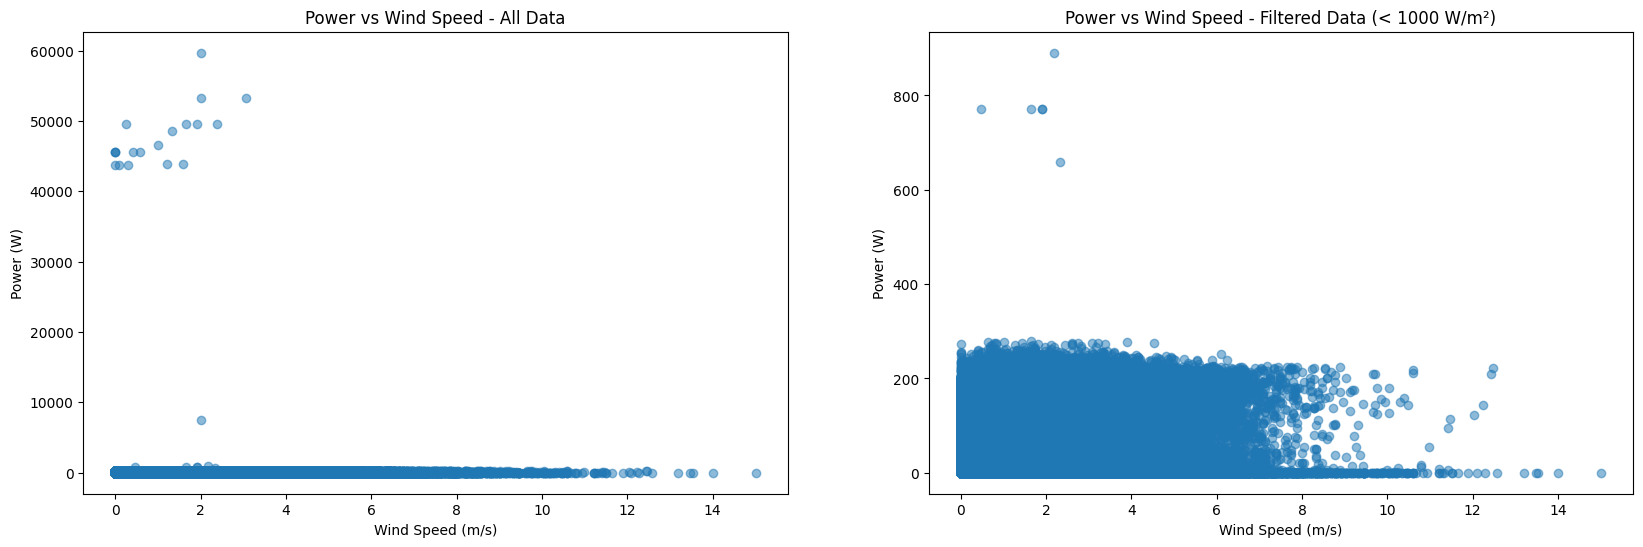

In [125]:
# Graph 5: Power vs Wind Speed

fig, axs = plt.subplots(1, 2, figsize=(20, 6))
axs[0].scatter(df["Wind_speed"], df["Power_W"], alpha=0.5)
axs[0].set_xlabel("Wind Speed (m/s)")
axs[0].set_ylabel("Power (W)")
axs[0].set_title("Power vs Wind Speed - All Data")
filtered_df = df[df["Power_W"] < 1000]
axs[1].scatter(filtered_df["Wind_speed"], filtered_df["Power_W"], alpha=0.5)
axs[1].set_xlabel("Wind Speed (m/s)")
axs[1].set_ylabel("Power (W)")
axs[1].set_title("Power vs Wind Speed - Filtered Data (< 1000 W/m²)")
plt.show()

save_path = image_path + "power_vs_wind_speed.png"
fig.savefig(save_path)

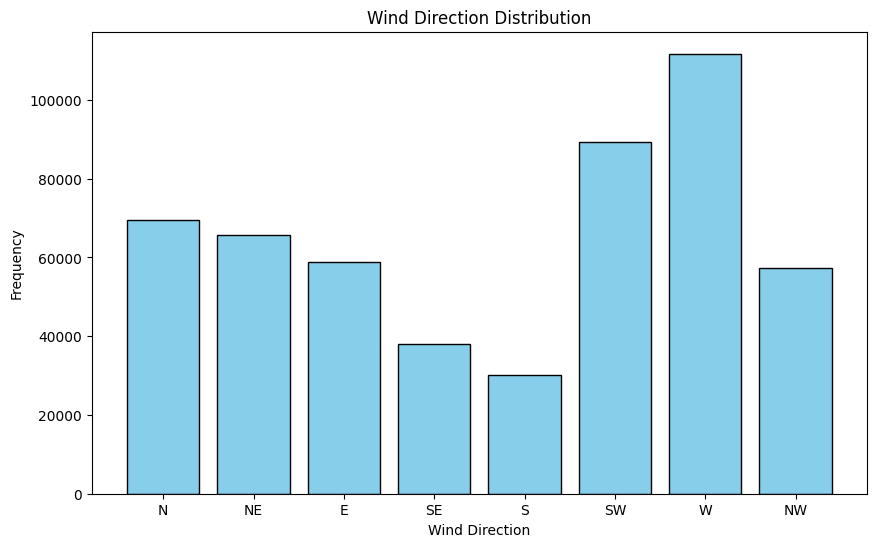

In [126]:
# Graph 6: Wind Direction Distribution

fig, ax = plt.subplots(figsize=(10, 6))
wind_direction_counts = df['Wind_direction_encoded'].value_counts()
wind_direction_counts = wind_direction_counts.reindex(labels, fill_value=0)
ax.bar(wind_direction_counts.index, wind_direction_counts.values, color='skyblue', edgecolor='black')
ax.set_xlabel("Wind Direction")
ax.set_ylabel("Frequency")
ax.set_title("Wind Direction Distribution")
plt.show()

save_path = image_path + "wind_direction_distribution.png"
fig.savefig(save_path)